In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [85]:
df = pd.read_csv("Social_Network_Ads.csv")
df = df.iloc[:,2:]

In [86]:
df.sample(5)

,Age,EstimatedSalary,Purchased
100,27,88000,0
98,35,73000,0
321,53,82000,1
285,37,93000,1
187,33,41000,0


In [87]:
x_train ,x_test , y_train ,y_test = train_test_split(df.drop("Purchased",axis = 1),df["Purchased"],
                                                     test_size=0.3,random_state = 0)

x_train.shape,x_test.shape

((280, 2), (120, 2))

In [88]:
scaler = StandardScaler()
scaler.fit(x_train)
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

In [89]:
x_train_s = pd.DataFrame(x_train_s, columns=x_train.columns)
x_test_s = pd.DataFrame(x_test_s, columns=x_test.columns)

In [90]:
x_train_s

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [91]:
np.round(x_train_s.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


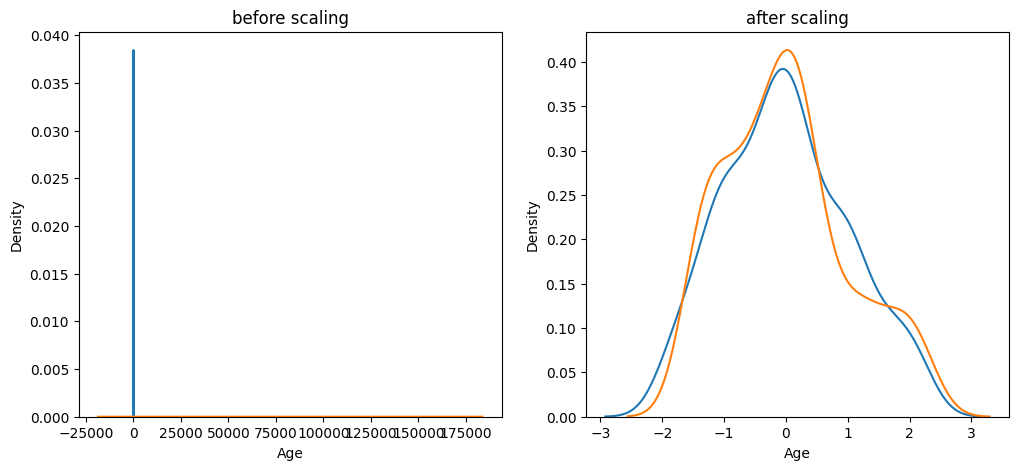

In [101]:
fig ,(ax1,ax2) = plt.subplots(1, 2 ,figsize = (12,5) )

# ax1.scatter(x_train_s["Age"],x_train_s["EstimatedSalary"])
# ax1.set_title("after train")
# ax2.scatter(x_test_s["Age"],x_test_s["EstimatedSalary"],color = "m")
# ax2.set_title("after test")
# plt.show()
ax1.set_title("before scaling")
sns.kdeplot(x_train["Age"],ax = ax1)
sns.kdeplot(x_train["EstimatedSalary"],ax = ax1)

ax2.set_title("after scaling")
sns.kdeplot(x_train_s["Age"],ax = ax2)
sns.kdeplot(x_train_s["EstimatedSalary"],ax = ax2)

plt.show()


In [95]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [96]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_s,y_train)

LogisticRegression()

In [102]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_s)

In [104]:
y_pred_scaled

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1])

In [105]:
print(accuracy_score(y_test,y_pred))
print(accuracy_score(y_test,y_pred_scaled))

0.875
0.8666666666666667
